# Problem Set 7

Solutions to Computational Problems

## Problem 1

In [52]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

### Data Management

In [2]:
raw_data = pd.read_stata("data/LM2007.dta")

CUTOFF = 59.1984
BANDWIDTH = 19.6

In [35]:
def clean_data(raw_data: pd.DataFrame) -> pd.DataFrame:
    """Create clean data set as required for the analysis.

    Args:
        raw_data: The raw data set.

    Returns:
        The cleaned data set.

    """
    new_data = pd.DataFrame()
    new_data["poverty_rate"] = raw_data["povrate60"]
    new_data["mortality_rate"] = raw_data["mort_age59_related_postHS"]
    return new_data

In [36]:
data = clean_data(raw_data)

### Data Visualization


#### Problem 1 (a)

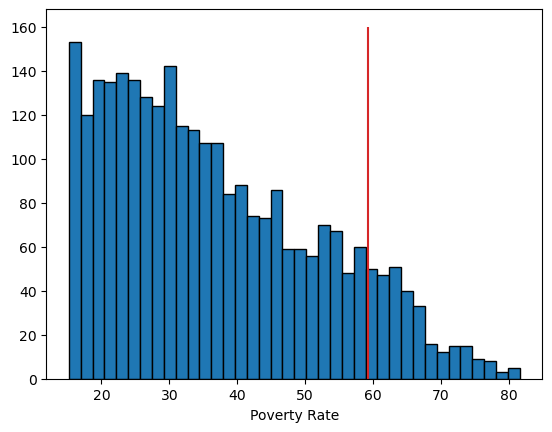

In [37]:
plt.hist(data["poverty_rate"], bins=38, ec="black", color="tab:blue")
plt.vlines(CUTOFF, 0, 160, colors="tab:red")
plt.xlabel("Poverty Rate")
plt.show()

### Analysis


#### Problem 1 (b) - (d)

In [122]:
def triangular_kernel(u):
    """Unnormalized triangular kernel."""
    return np.clip(1 - np.abs(u), 0, 1)


def _local_linear_mean_estimate(
    new_x: float,
    x: np.ndarray,
    y: np.ndarray,
    *,
    cutoff: float = CUTOFF,
    kernel: callable = triangular_kernel,
    bandwidth: float = BANDWIDTH,
) -> dict[str, float]:
    """Calculate local linear mean estimate."""
    below_cutoff = x < cutoff
    above_cutoff = x >= cutoff

    z = np.column_stack((np.ones_like(x), x - new_x))
    k = kernel((x - new_x) / bandwidth)

    zk = z * k.reshape(-1, 1)
    beta_below = np.linalg.lstsq(zk[below_cutoff], y[below_cutoff], rcond=None)[0]
    beta_above = np.linalg.lstsq(zk[above_cutoff], y[above_cutoff], rcond=None)[0]

    return {
        "mean_below": beta_below[0],
        "mean_above": beta_above[0],
    }


def calculate_leave_one_out_residuals(
    x: np.ndarray | pd.Series,
    y: np.ndarray | pd.Series,
    *,
    cutoff: float = CUTOFF,
    kernel: callable = triangular_kernel,
    bandwidth: float = BANDWIDTH,
) -> np.ndarray:
    """Calculate leave-one-out residuals."""
    if not isinstance(x, np.ndarray):
        x = np.array(x)
    if not isinstance(y, np.ndarray):
        y = np.array(y)

    prediction_error = np.empty_like(y)

    for i in range(len(x)):

        x_i = x[i]

        estimate = _local_linear_mean_estimate(
            new_x=x_i,
            x=np.delete(x, i),
            y=np.delete(y, i),
            cutoff=cutoff,
            kernel=kernel,
            bandwidth=bandwidth,
        )

        m_hat = estimate["mean_below"] * (x_i < cutoff) + estimate["mean_above"] * (
            x_i >= cutoff
        )
        prediction_error[i] = y[i] - m_hat

    return prediction_error


def _local_linear_mean_estimate_sd(
    new_x: float,
    x: np.ndarray,
    residuals: np.ndarray,
    *,
    cutoff: float = CUTOFF,
    kernel: callable = triangular_kernel,
    bandwidth: float = BANDWIDTH,
) -> float:
    """Calculate local linear mean estimate standard error."""
    below_cutoff = x < cutoff
    above_cutoff = x >= cutoff

    z = np.column_stack((np.ones_like(x), x - new_x))
    k = kernel((x - new_x) / bandwidth)

    k_zz = (k.reshape(-1, 1, 1) * z.reshape(-1, 2, 1)) @ z.reshape(-1, 1, 2)

    k_zz_0_inv = np.linalg.pinv(k_zz[below_cutoff].sum(axis=0))
    k_zz_1_inv = np.linalg.pinv(k_zz[above_cutoff].sum(axis=0))

    k_sqrd_zz_e_sqrd = (
        ((k * residuals) ** 2).reshape(-1, 1, 1) * z.reshape(-1, 2, 1)
    ) @ z.reshape(-1, 1, 2)

    v_hat_0 = k_zz_0_inv @ k_sqrd_zz_e_sqrd[below_cutoff].sum(axis=0) @ k_zz_0_inv
    v_hat_1 = k_zz_1_inv @ k_sqrd_zz_e_sqrd[above_cutoff].sum(axis=0) @ k_zz_1_inv

    return {
        "var_below": v_hat_0[0, 0],
        "var_above": v_hat_1[0, 0],
    }


def _local_linear_estimator(
    new_x: float,
    x: np.ndarray | pd.Series,
    y: np.ndarray | pd.Series,
    residuals: np.ndarray,
    *,
    cutoff: float = CUTOFF,
    kernel: callable = triangular_kernel,
    bandwidth: float = BANDWIDTH,
    estimate_rdd_cate: bool = False,
) -> dict[str, float]:

    if not isinstance(x, np.ndarray):
        x = np.array(x)
    if not isinstance(y, np.ndarray):
        y = np.array(y)

    mean_estimate = _local_linear_mean_estimate(
        new_x=new_x,
        x=x,
        y=y,
        cutoff=cutoff,
        kernel=kernel,
        bandwidth=bandwidth,
    )

    variance_estimate = _local_linear_mean_estimate_sd(
        new_x=new_x,
        x=x,
        cutoff=cutoff,
        kernel=kernel,
        bandwidth=bandwidth,
        residuals=residuals,
    )

    if estimate_rdd_cate:

        estimate = mean_estimate["mean_above"] - mean_estimate["mean_below"]
        se = np.sqrt(variance_estimate["var_below"] + variance_estimate["var_above"])

    else:

        below_or_above = "below" if new_x < cutoff else "above"

        estimate = mean_estimate[f"mean_{below_or_above}"]
        se = np.sqrt(variance_estimate[f"var_{below_or_above}"])

    return {
        "mean": estimate,
        "se": se,
    }


def local_linear_estimator(
    new_x: np.ndarray,
    x: np.ndarray | pd.Series,
    y: np.ndarray | pd.Series,
    residuals: np.ndarray,
    *,
    cutoff: float = CUTOFF,
    kernel: callable = triangular_kernel,
    bandwidth: float = BANDWIDTH,
    estimate_rdd_cate: bool = False,
) -> dict[str, np.ndarray]:

    is_scalar = np.isscalar(new_x)

    if is_scalar:
        new_x = np.array([new_x])
    data = [
        _local_linear_estimator(
            new_x=new_x_i,
            x=x,
            y=y,
            residuals=residuals,
            cutoff=cutoff,
            kernel=kernel,
            bandwidth=bandwidth,
            estimate_rdd_cate=estimate_rdd_cate,
        )
        for new_x_i in new_x
    ]

    if is_scalar:
        out = data[0]
    else:
        out = {
            "mean": np.array([d["mean"] for d in data]),
            "se": np.array([d["se"] for d in data]),
        }
    return out


In [123]:
leave_one_out_residuals = calculate_leave_one_out_residuals(
    x=data["poverty_rate"],
    y=data["mortality_rate"],
)

In [124]:
x_grid = np.arange(15, 82)

estimate = local_linear_estimator(
    new_x=x_grid,
    x=data["poverty_rate"],
    y=data["mortality_rate"],
    residuals=leave_one_out_residuals,
)

below_cutoff = x_grid < CUTOFF
above_cutoff = x_grid >= CUTOFF

Text(0, 0.5, 'Mortality Rate')

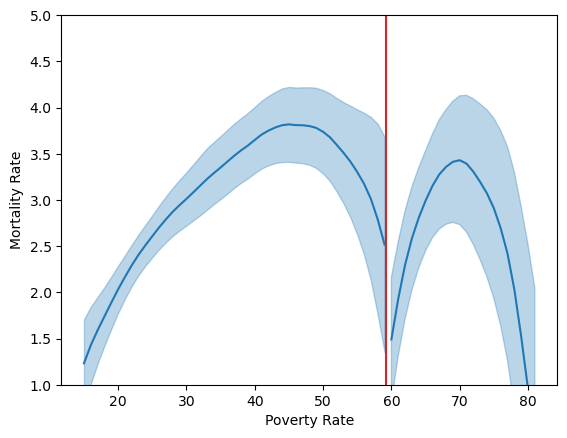

In [125]:
plt.plot(x_grid[below_cutoff], estimate["mean"][below_cutoff], color="tab:blue")
plt.plot(x_grid[above_cutoff], estimate["mean"][above_cutoff], color="tab:blue")
plt.fill_between(
    x_grid[below_cutoff],
    estimate["mean"][below_cutoff] - 1.96 * estimate["se"][below_cutoff],
    estimate["mean"][below_cutoff] + 1.96 * estimate["se"][below_cutoff],
    alpha=0.3,
    color="tab:blue",
)
plt.fill_between(
    x_grid[above_cutoff],
    estimate["mean"][above_cutoff] - 1.96 * estimate["se"][above_cutoff],
    estimate["mean"][above_cutoff] + 1.96 * estimate["se"][above_cutoff],
    alpha=0.3,
    color="tab:blue",
)
plt.ylim(1, 5)
plt.vlines(CUTOFF, 1, 5, colors="tab:red")
plt.xlabel("Poverty Rate")
plt.ylabel("Mortality Rate")

### Problem 1 (e)

In [126]:
local_linear_estimator(
    new_x=CUTOFF,
    x=data["poverty_rate"],
    y=data["mortality_rate"],
    residuals=leave_one_out_residuals,
    estimate_rdd_cate=True,
)

{'mean': -1.3708963, 'se': 0.71383584}